#### CNN(Convolution Neural Network : 합성곱 신경망)

##### CNN 입장에서 본 심층신경망의 단점
- 입력값으로 고유 이미지 생김새 정보를 알 수 없다.(2차원 -> 1차원 변경후 작업)
- 심층신경망은 픽셀 하나 하나의 변화에 상당히 민감하다.
- 이미지 생김새를 사용할 수 없으므로 한 두개의 픽셀이 모델 전체에 영향을 끼친다.
- 픽셀 한 두개의 정보에도 민감하게 반응하기 위해 상당히 많은 변수를                 
모델안에 가지고 있다. 이로 인해 학습시간이 오래 걸리고 잘못하면 과대적합이 발생한다.

#### 밀집층(Dense)
- 1차원 구조
- 밀집층의 뉴런(노드)를 여러개 사용해서 신경망 알고리즘 출력을 만듬
- 이미지는 원래 2차원인데 이를 1차원으로 만들어 처리하므로 이미지 모양은 없어짐
- 원래 이미지는 2차원이니까 이를 2차원으로 처리 할 수 있는 방법이 합성곱 신경망 이다.

#### 합성곱층
- 이미지 크기가 4*4
- 필터의 커널을 3*3이고 각 입력층에 곱해지는 weight와 bias는 동일
- 발생하는 출력의 갯수는 4개 : 특성 맵
- 특성맵의 구성은 가로*세로*필터의 갯수를 3차원이 생성

#### 특성맵
- 특성맵을 활성화 출력 이라고도 한다.
- 커널 특성맵 사이에 활성화 함수(relu)가 들어가 있기 때문이다.
- CNN에서는 특성맵이 Feature Map

#### Padding
- 입력값과 특성맵의 크기를 동일시 하자
- same padding : padding을 사용
- valid padding : padding을 사용하지 않음

#### Stride
- 특성맵을 구성할 경우 filter의 움직이는 거리

합성곱층을 여러개 준 경우는 심층합성공 신경망이라고 한다.

In [33]:
from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0 #(Dimension, Row, Column, Channel)

train_scaled, val_scaled, train_target, val_target = \
        train_test_split(
            train_scaled,
            train_target,
            test_size=0.2,
            random_state=42
        )

In [34]:
model = keras.Sequential()

In [35]:
model.add(
    keras.layers.Conv2D(
        32, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding = 'same', # valid
        input_shape = (28, 28, 1)
    )
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 풀링충

In [36]:
model.add(
    keras.layers.MaxPooling2D(2) # 2*2 max pooling 
)

#### 두번째 합성곱층

In [37]:
model.add(
    keras.layers.Conv2D(
        64, # Filter의 갯수
        kernel_size=3, # 보통 정사각형으로 구성
        activation='relu', # 활성화 함수
        padding = 'same', # valid
    )
)

model.add(
    keras.layers.MaxPooling2D(2) # 2*2 max pooling 
)

#### Dense 층

In [38]:
# 입력층
model.add(
    keras.layers.Flatten()
)

# 은닉층
model.add(
    keras.layers.Dense(
        100,
        activation='relu'
    )
)

# Drop out층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        10,
        activation='softmax'
    )
)

In [39]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#### Model Compile

In [40]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_model.keras")

early_stopping_cb= keras.callbacks.EarlyStopping(
                    patience=2,
                    restore_best_weights=True                  
)

history = model.fit(
            train_scaled,
            train_target,
            epochs=20,
            validation_data=(val_scaled, val_target),
            callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7798 - loss: 0.6070 - val_accuracy: 0.8608 - val_loss: 0.3699
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8543 - loss: 0.4024 - val_accuracy: 0.8903 - val_loss: 0.2939
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8759 - loss: 0.3428 - val_accuracy: 0.8947 - val_loss: 0.2740
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8892 - loss: 0.3079 - val_accuracy: 0.9072 - val_loss: 0.2510
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8985 - loss: 0.2800 - val_accuracy: 0.9127 - val_loss: 0.2337
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9062 - loss: 0.2588 - val_accuracy: 0.9140 - val_loss: 0.2300
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9129 - loss: 0.2410 - val_accuracy: 0.9128 - val_loss: 0.2386
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9175 - loss: 

In [41]:
# 복원
model1 = keras.models.load_model("../Data/best_cnn_model.keras")
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9192 - loss: 0.2393


[0.23932088911533356, 0.9191666841506958]

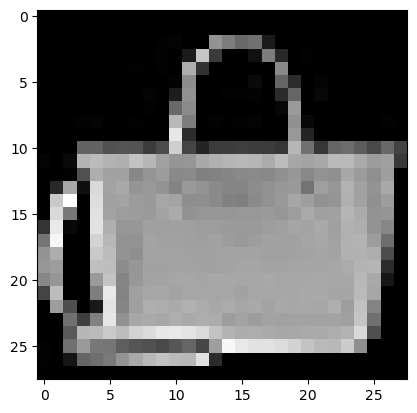

In [42]:
import matplotlib.pyplot as plt

plt.imshow(
    val_scaled[0].reshape(28, 28),
    cmap='gray'
)

plt.show()

In [43]:
pred = model.predict(
    val_scaled[:1]
)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([[3.0012005e-19, 5.9596876e-32, 1.8514770e-27, 1.6738033e-23,
        6.6602309e-27, 7.8271170e-23, 8.7465136e-23, 5.7232086e-23,
        1.0000000e+00, 5.9088679e-24]], dtype=float32)

In [44]:
# 글자로 변경하기
import numpy as np
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵글부츠']
len(classes)

10

In [45]:
classes[np.argmax(pred)]

'가방'

#### test data로 확인하기

In [47]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9139 - loss: 0.2421


[0.24212197959423065, 0.9139000177383423]